# Data Analysis Challenge - PESTA 2026
# Churn Prediction - IBM Telco Customer
## Track B: Churn Prediction

**Bagus Arya Dwipangga - Statistika, Universitas Negeri Jakarta**

**Tujuan**: Memprediksi apakah pelanggan akan churn (berhenti berlangganan) menggunakan model Logistic Regression dan Random Forest.

**Dataset**: IBM Telco Customer Churn (7043 baris, 25 kolom)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
url = 'https://raw.githubusercontent.com/BagusAryaD/Data-Analysis-Challenge-PESTA2026/refs/heads/main/Dataset/ibm-telco-churn-prediction%20-%20ibm-telco-churn-prediction.csv'
df = pd.read_csv(url)
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 25)


,customer_id,gender_female,senior_citizen,has_partner,has_dependents,tenure_months,has_phone_service,has_multiple_lines,internet_dsl,internet_fiber_optic,...,has_streaming_movies,contract_one_year,contract_two_year,paperless_billing,payment_bank_transfer_auto,payment_credit_card_auto,payment_electronic_check,monthly_charges,total_charges,churn
0,7590-VHVEG,1,0,1,0,1,0,0,1,0,...,0,0,0,1,0,0,1,29.85,29.85,0
1,5575-GNVDE,0,0,0,0,34,1,0,1,0,...,0,1,0,0,0,0,0,56.95,1889.50,0
2,3668-QPYBK,0,0,0,0,2,1,0,1,0,...,0,0,0,1,0,0,0,53.85,108.15,1
3,7795-CFOCW,0,0,0,0,45,0,0,1,0,...,0,1,0,0,1,0,0,42.30,1840.75,0
4,9237-HQITU,1,0,0,0,2,1,0,0,1,...,0,0,0,1,0,0,1,70.70,151.65,1


# 1. Eksplorasi Data

Memahami struktur data, tipe fitur, distribusi target, dan kualitas data sebelum preprocessing.

## 1.1 Struktur Data & Tipe Kolom

In [3]:
df.info()
print(f'\nJumlah duplicate customer_id: {df["customer_id"].duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 7043 non-null   object 
 1   gender_female               7043 non-null   int64  
 2   senior_citizen              7043 non-null   int64  
 3   has_partner                 7043 non-null   int64  
 4   has_dependents              7043 non-null   int64  
 5   tenure_months               7043 non-null   int64  
 6   has_phone_service           7043 non-null   int64  
 7   has_multiple_lines          7043 non-null   int64  
 8   internet_dsl                7043 non-null   int64  
 9   internet_fiber_optic        7043 non-null   int64  
 10  has_online_security         7043 non-null   int64  
 11  has_online_backup           7043 non-null   int64  
 12  has_device_protection       7043 non-null   int64  
 13  has_tech_support            7043 

## 1.2 Distribusi Target (Churn)

Distribusi Churn:
  Tidak Churn (0): 5174 (73.5%)
  Churn (1): 1869 (26.5%)

Rasio: 2.77:1 (minoritas churn)


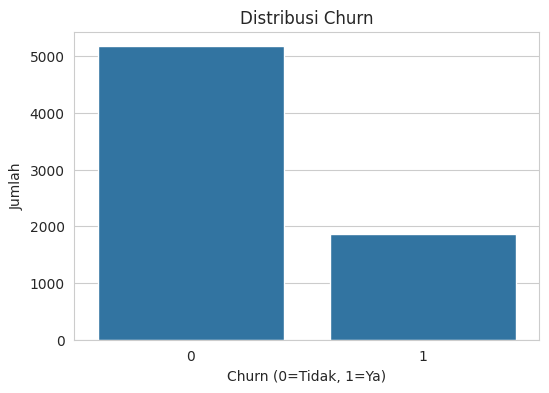

In [4]:
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

print('Distribusi Churn:')
print(f'  Tidak Churn (0): {churn_counts[0]} ({churn_pct[0]:.1f}%)')
print(f'  Churn (1): {churn_counts[1]} ({churn_pct[1]:.1f}%)')
print(f'\nRasio: {churn_counts[0]/churn_counts[1]:.2f}:1 (minoritas churn)')

plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df)
plt.title('Distribusi Churn')
plt.xlabel('Churn (0=Tidak, 1=Ya)')
plt.ylabel('Jumlah')
plt.show()

## 1.3 Missing Values

In [5]:
print('Jumlah missing values per kolom:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values')
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Jumlah missing values per kolom:
Tidak ada missing values

Total missing: 0


## 1.4 Statistik Deskriptif Fitur Numerik

In [6]:
num_cols = ['tenure_months', 'monthly_charges', 'total_charges']
print('Statistik Deskriptif Fitur Numerik:')
df[num_cols].describe().round(2)

Statistik Deskriptif Fitur Numerik:


,tenure_months,monthly_charges,total_charges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


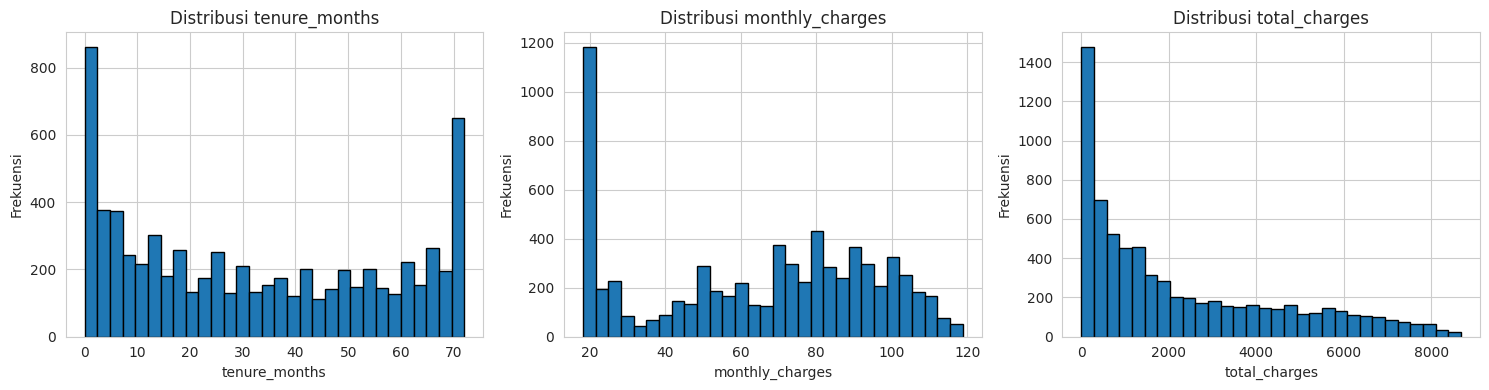

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# 2. Analisis Multikolinearitas

Memeriksa korelasi antar fitur untuk mengidentifikasi fitur redundan yang perlu dihapus agar model lebih parsimonious dan stabil.

## 2.1 Korelasi Antar Fitur Numerik

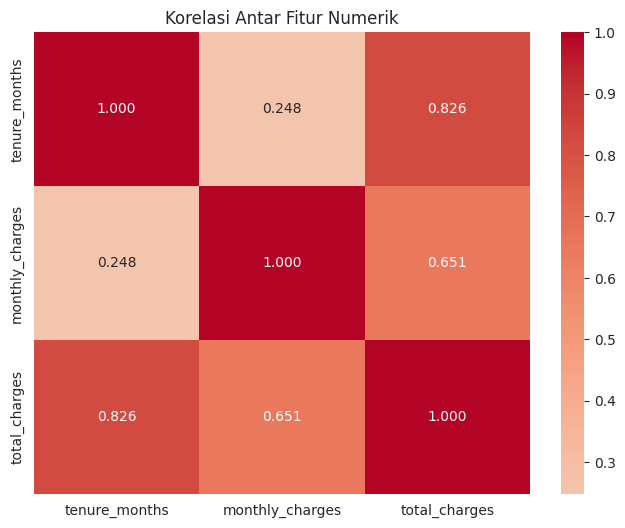

Korelasi dengan total_charges:
  total_charges vs tenure_months: 0.826
  total_charges vs monthly_charges: 0.651


In [8]:
plt.figure(figsize=(8, 6))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Korelasi Antar Fitur Numerik')
plt.show()

print('Korelasi dengan total_charges:')
for col in ['tenure_months', 'monthly_charges']:
    r = corr_matrix.loc['total_charges', col]
    print(f'  total_charges vs {col}: {r:.3f}')

## 2.2 Variance Inflation Factor (VIF)

VIF mengukur seberapa besar variance koefisien regresi meningkat karena multikolinearitas. VIF > 10 menunjukkan multikolinearitas tinggi.

In [9]:
print('VIF (Variance Inflation Factor) untuk Fitur Numerik:')
print('(VIF > 10 menunjukkan multikolinearitas tinggi)\n')

X_vif = df[num_cols].values
vif_data = pd.DataFrame()
vif_data['Feature'] = num_cols
vif_data['VIF'] = [variance_inflation_factor(X_vif, i) for i in range(len(num_cols))]
print(vif_data.round(2))

VIF (Variance Inflation Factor) untuk Fitur Numerik:
(VIF > 10 menunjukkan multikolinearitas tinggi)

           Feature   VIF
0    tenure_months  6.33
1  monthly_charges  3.36
2    total_charges  8.08


## 2.3 Verifikasi total_charges sebagai Fitur Redundan

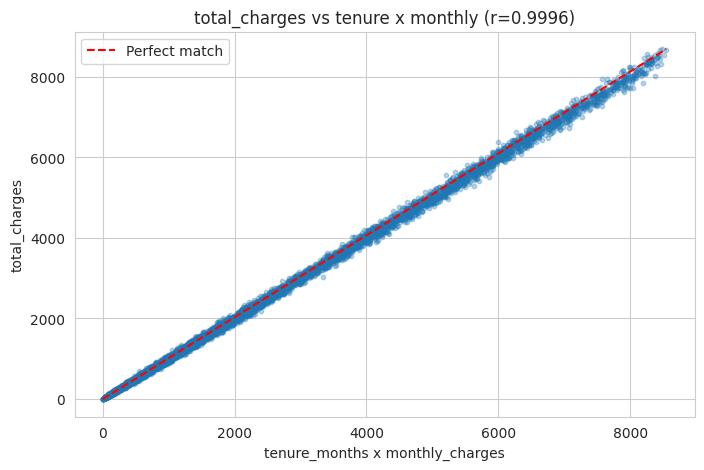

In [10]:
df['approx_total'] = df['tenure_months'] * df['monthly_charges']
corr_approx = df['total_charges'].corr(df['approx_total'])

plt.figure(figsize=(8, 5))
plt.scatter(df['approx_total'], df['total_charges'], alpha=0.3, s=10)
plt.plot([0, df['approx_total'].max()], [0, df['total_charges'].max()],
         'r--', label='Perfect match')
plt.xlabel('tenure_months x monthly_charges')
plt.ylabel('total_charges')
plt.title(f'total_charges vs tenure x monthly (r={corr_approx:.4f})')
plt.legend()
plt.show()

df.drop(columns=['approx_total'], inplace=True)

## 2.4 Korelasi Fitur dengan Target (Churn)

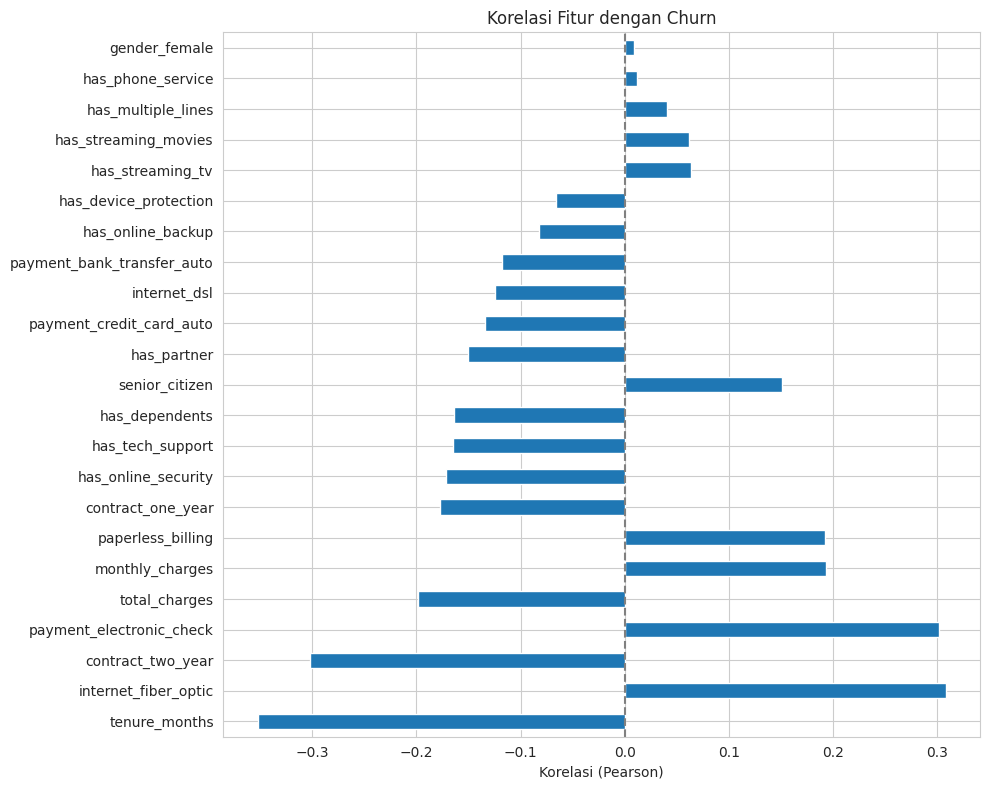

Top 10 Fitur dengan Korelasi Tertinggi:
tenure_months              -0.3522
internet_fiber_optic        0.3080
contract_two_year          -0.3023
payment_electronic_check    0.3019
total_charges              -0.1983
monthly_charges             0.1934
paperless_billing           0.1918
contract_one_year          -0.1778
has_online_security        -0.1712
has_tech_support           -0.1647
Name: churn, dtype: float64


In [11]:
corr_with_churn = df.drop(columns=['customer_id']).corr()['churn'].drop('churn')
corr_with_churn = corr_with_churn.sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 8))
corr_with_churn.plot(kind='barh')
plt.title('Korelasi Fitur dengan Churn')
plt.xlabel('Korelasi (Pearson)')
plt.axvline(x=0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

print('Top 10 Fitur dengan Korelasi Tertinggi:')
print(corr_with_churn.head(10).round(4))

## 2.5 Fitur Mutually Exclusive

Fitur biner yang merepresentasikan satu kategori yang sama tidak menimbulkan perfect multicollinearity karena memiliki reference category (semua = 0).

In [12]:
print('=== Pengecekan Grup Fitur Mutually Exclusive ===\n')

inet_cols = ['internet_dsl', 'internet_fiber_optic']
inet_sum = df[inet_cols].sum(axis=1)
print(f'Internet Group (sum per baris): min={inet_sum.min()}, max={inet_sum.max()}')
print(f'  0 = tidak ada internet: {(inet_sum == 0).sum()} orang')
print(f'  1 = salah satu aktif: {(inet_sum == 1).sum()} orang')

contract_cols = ['contract_one_year', 'contract_two_year']
contract_sum = df[contract_cols].sum(axis=1)
print(f'\nContract Group (sum per baris): min={contract_sum.min()}, max={contract_sum.max()}')
print(f'  0 = month-to-month: {(contract_sum == 0).sum()} orang')
print(f'  1 = salah satu aktif: {(contract_sum == 1).sum()} orang')

payment_cols = ['payment_bank_transfer_auto', 'payment_credit_card_auto', 'payment_electronic_check']
payment_sum = df[payment_cols].sum(axis=1)
print(f'\nPayment Group (sum per baris): min={payment_sum.min()}, max={payment_sum.max()}')
print(f'  0 = mailed check: {(payment_sum == 0).sum()} orang')
print(f'  1 = salah satu aktif: {(payment_sum == 1).sum()} orang')

=== Pengecekan Grup Fitur Mutually Exclusive ===

Internet Group (sum per baris): min=0, max=1
  0 = tidak ada internet: 1526 orang
  1 = salah satu aktif: 5517 orang

Contract Group (sum per baris): min=0, max=1
  0 = month-to-month: 3875 orang
  1 = salah satu aktif: 3168 orang

Payment Group (sum per baris): min=0, max=1
  0 = mailed check: 1612 orang
  1 = salah satu aktif: 5431 orang


# 3. Seleksi Fitur

Berdasarkan analisis multikolinearitas dan korelasi dengan target, beberapa fitur dihapus untuk model yang lebih parsimonious.

### Fitur yang Dihapus (5)
| Fitur | Alasan |
|-------|--------|
| customer_id | Identifier, bukan fitur prediktif |
| total_charges | Redundan, hampir identik dengan tenure_months x monthly_charges (r=0.9996), VIF tinggi |
| gender_female | Korelasi sangat rendah dengan churn (0.009) |
| has_phone_service | Korelasi sangat rendah (0.012), hampir selalu bernilai 1 |
| has_multiple_lines | Korelasi rendah (0.040), informasi sudah tercakup oleh phone service |

### Fitur yang Digunakan (20 fitur)
- **Numerik (2):** tenure_months, monthly_charges
- **Binari (18):** fitur internet, contract, payment, dan demografi lainnya

In [13]:
drop_cols = ['customer_id', 'total_charges', 'gender_female',
             'has_phone_service', 'has_multiple_lines']

X = df.drop(columns=drop_cols + ['churn'])
y = df['churn']

print(f'Jumlah fitur setelah seleksi: {X.shape[1]}')
print(f'\nFitur yang digunakan:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i}. {col}')

Jumlah fitur setelah seleksi: 19

Fitur yang digunakan:
  1. senior_citizen
  2. has_partner
  3. has_dependents
  4. tenure_months
  5. internet_dsl
  6. internet_fiber_optic
  7. has_online_security
  8. has_online_backup
  9. has_device_protection
  10. has_tech_support
  11. has_streaming_tv
  12. has_streaming_movies
  13. contract_one_year
  14. contract_two_year
  15. paperless_billing
  16. payment_bank_transfer_auto
  17. payment_credit_card_auto
  18. payment_electronic_check
  19. monthly_charges


# 4. Persiapan Modeling

- **Stratified Train-Test Split (80/20)**: menjaga proporsi churn tetap konsisten di train dan test set
- **Scaling**: hanya untuk fitur numerik pada Logistic Regression (Random Forest tidak membutuhkan scaling)
- **Class weight**: `balanced` digunakan di kedua model untuk menangani ketidakseimbangan kelas tanpa oversampling/undersampling

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set: {X_train.shape[0]} sampel')
print(f'Test set: {X_test.shape[0]} sampel')
print(f'\nDistribusi Churn:')
print(f'  Train: {y_train.value_counts().to_dict()}')
print(f'  Test:  {y_test.value_counts().to_dict()}')

Train set: 5634 sampel
Test set: 1409 sampel

Distribusi Churn:
  Train: {0: 4139, 1: 1495}
  Test:  {0: 1035, 1: 374}


In [15]:
num_features = ['tenure_months', 'monthly_charges']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

print('Scaling selesai (hanya untuk numerik):')
print(f'  tenure_months - Train mean: {X_train_scaled["tenure_months"].mean():.4f}, std: {X_train_scaled["tenure_months"].std():.4f}')
print(f'  monthly_charges - Train mean: {X_train_scaled["monthly_charges"].mean():.4f}, std: {X_train_scaled["monthly_charges"].std():.4f}')

Scaling selesai (hanya untuk numerik):
  tenure_months - Train mean: -0.0000, std: 1.0001
  monthly_charges - Train mean: -0.0000, std: 1.0001


# 5. Model 1: Logistic Regression

### Alasan Pemilihan
- Model interpretabel, koefisien regresi menunjukkan arah dan magnitudo pengaruh fitur terhadap log-odds churn
- Cocok sebagai baseline untuk perbandingan dengan model lebih kompleks
- Menggunakan `class_weight='balanced'` untuk menangani imbalance tanpa resampling

### Hyperparameter yang Dituning
- **C**: kekuatan regularisasi (semakin kecil = regularisasi lebih kuat)
- **penalty**: L1 (sparse) atau L2 (default)
- **solver**: `liblinear` (cocok untuk dataset berukuran sedang dan regularisasi L1/L2)

In [16]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

lr = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42, max_iter=1000)
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)

print(f'Best Parameters: {grid_lr.best_params_}')
print(f'Best F1 Score (CV): {grid_lr.best_score_:.4f}')

Best Parameters: {'C': 10, 'penalty': 'l2'}
Best F1 Score (CV): 0.6308


## 5.1 Evaluasi Logistic Regression

=== Logistic Regression - Evaluasi Test Set ===

Confusion Matrix:
[[751 284]
 [ 81 293]]


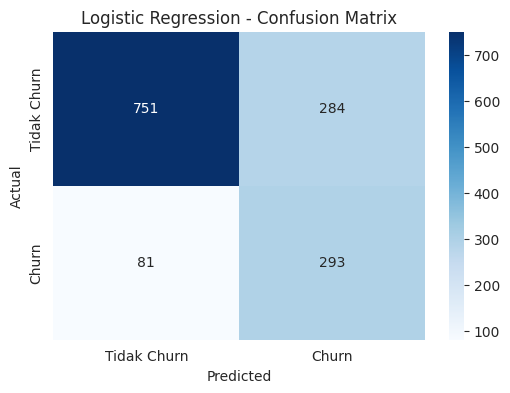


Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.90      0.73      0.80      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [17]:
y_pred_lr = grid_lr.predict(X_test_scaled)

print('=== Logistic Regression - Evaluasi Test Set ===\n')
print('Confusion Matrix:')
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Churn', 'Churn'],
            yticklabels=['Tidak Churn', 'Churn'])
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Tidak Churn', 'Churn']))

## 5.2 Koefisien Logistic Regression

Koefisien regresi menunjukkan pengaruh setiap fitur terhadap **log-odds** churn:
- **Koefisien positif**: meningkatkan kemungkinan churn
- **Koefisien negatif**: menurunkan kemungkinan churn
- **Magnitudo**: semakin besar absolut koefisien, semakin kuat pengaruhnya

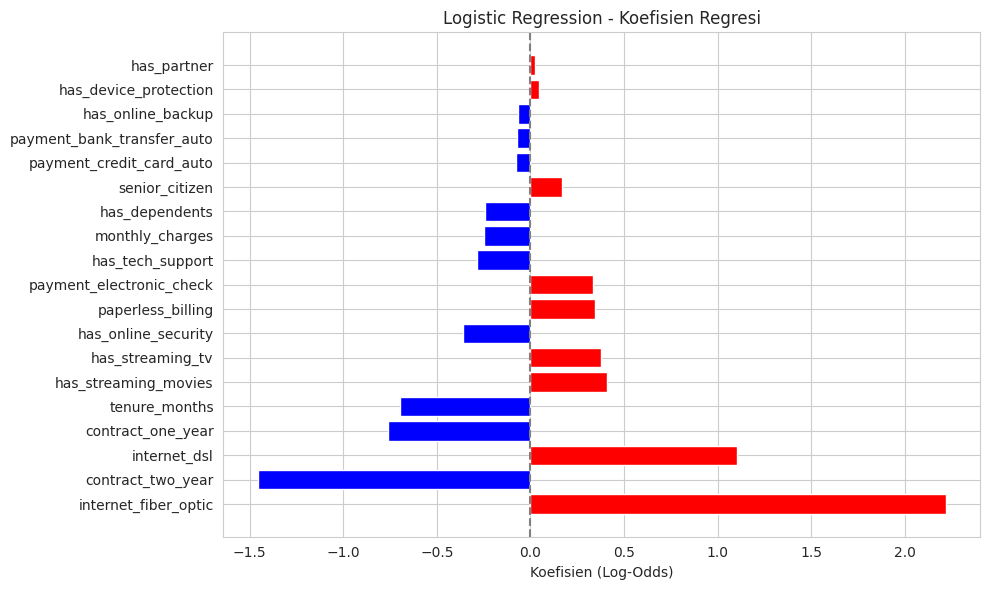

Koefisien (diurutkan berdasarkan magnitudo):
                   Feature  Coefficient
      internet_fiber_optic     2.219078
         contract_two_year    -1.457071
              internet_dsl     1.102835
         contract_one_year    -0.760993
             tenure_months    -0.697365
      has_streaming_movies     0.408505
          has_streaming_tv     0.379365
       has_online_security    -0.360214
         paperless_billing     0.343884
  payment_electronic_check     0.331644
          has_tech_support    -0.284157
           monthly_charges    -0.246869
            has_dependents    -0.243132
            senior_citizen     0.170475
  payment_credit_card_auto    -0.078518
payment_bank_transfer_auto    -0.074526
         has_online_backup    -0.066779
     has_device_protection     0.043351
               has_partner     0.024344


In [18]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': grid_lr.best_estimator_.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if x > 0 else 'blue' for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Koefisien (Log-Odds)')
plt.title('Logistic Regression - Koefisien Regresi')
plt.axvline(x=0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

print('Koefisien (diurutkan berdasarkan magnitudo):')
print(coef_df.to_string(index=False))

# 6. Model 2: Random Forest

### Alasan Pemilihan
- Tidak membutuhkan scaling, robust terhadap multikolinearitas
- Menghasilkan feature importance secara natural
- Dapat menangkap non-linear relationship
- Menggunakan `class_weight='balanced'` untuk menangani imbalance

### Hyperparameter yang Dituning
- **n_estimators**: jumlah pohon dalam forest
- **max_depth**: kedalaman maksimum tiap pohon
- **min_samples_split**: minimum sampel yang dibutuhkan untuk split node

In [19]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f'Best Parameters: {grid_rf.best_params_}')
print(f'Best F1 Score (CV): {grid_rf.best_score_:.4f}')

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best F1 Score (CV): 0.6396


## 6.1 Evaluasi Random Forest

=== Random Forest - Evaluasi Test Set ===

Confusion Matrix:
[[805 230]
 [106 268]]


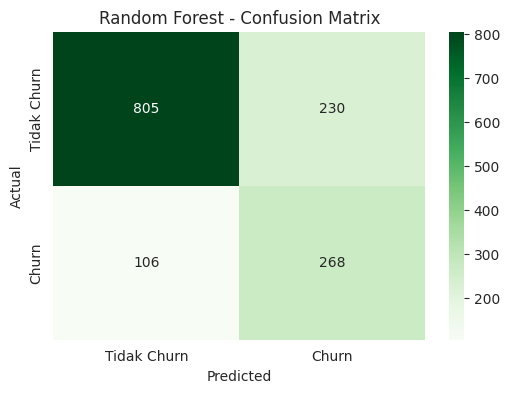


Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.88      0.78      0.83      1035
       Churn       0.54      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



In [20]:
y_pred_rf = grid_rf.predict(X_test)

print('=== Random Forest - Evaluasi Test Set ===\n')
print('Confusion Matrix:')
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Tidak Churn', 'Churn'],
            yticklabels=['Tidak Churn', 'Churn'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Tidak Churn', 'Churn']))

## 6.2 Feature Importance Random Forest

Feature importance menunjukkan seberapa sering fitur digunakan untuk splitting di seluruh pohon.

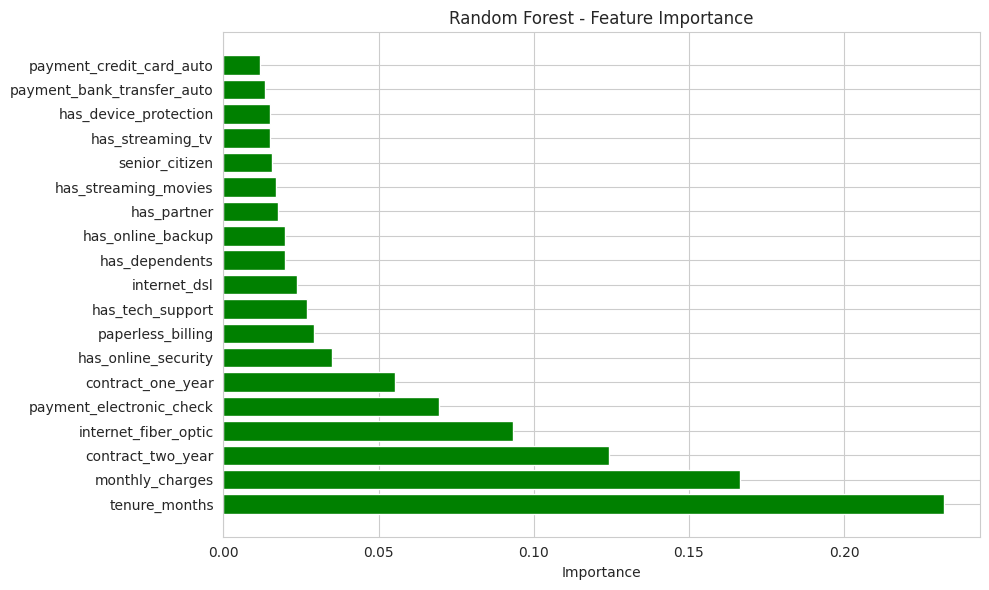

In [21]:
feature_imp_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': grid_rf.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_imp_rf['Feature'], feature_imp_rf['Importance'], color='green')
plt.xlabel('Importance')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

# 7. Perbandingan Model & Analisis Error

Membandingkan performa kedua model serta menganalisis kesalahan prediksi (False Positive dan False Negative).

In [22]:
f1_lr = f1_score(y_test, y_pred_lr)
f1_rf = f1_score(y_test, y_pred_rf)

cm_lr_vals = confusion_matrix(y_test, y_pred_lr).ravel()
cm_rf_vals = confusion_matrix(y_test, y_pred_rf).ravel()

comparison = pd.DataFrame({
    'Metric': ['F1-Score', 'True Neg', 'False Pos', 'False Neg', 'True Pos'],
    'Logistic Regression': [f1_lr, cm_lr_vals[0], cm_lr_vals[1], cm_lr_vals[2], cm_lr_vals[3]],
    'Random Forest': [f1_rf, cm_rf_vals[0], cm_rf_vals[1], cm_rf_vals[2], cm_rf_vals[3]]
})

print('Perbandingan Model:')
print(comparison.to_string(index=False))

Perbandingan Model:
   Metric  Logistic Regression  Random Forest
 F1-Score             0.616193       0.614679
 True Neg           751.000000     805.000000
False Pos           284.000000     230.000000
False Neg            81.000000     106.000000
 True Pos           293.000000     268.000000


## 7.1 Analisis Kesalahan Prediksi

- **False Negative (FN)**: Pelanggan yang sebenarnya churn tetapi diprediksi tidak churn. Ini adalah risiko terbesar karena pelanggan benar-benar pergi tanpa ditindaklanjuti.
- **False Positive (FP)**: Pelanggan yang sebenarnya tidak churn tetapi diprediksi churn. Ini menyebabkan alokasi sumber daya retensi yang tidak perlu.

In [23]:
# Analisis untuk Random Forest
errors_fn = X_test[(y_pred_rf == 0) & (y_test == 1)]
errors_fp = X_test[(y_pred_rf == 1) & (y_test == 0)]

print(f'False Negative (Churn tapi diprediksi tidak churn): {len(errors_fn)} orang')
print(f'False Positive (Tidak churn tapi diprediksi churn): {len(errors_fp)} orang')

print('\nKarakteristik False Negative (yang terlewat):')
print(errors_fn[num_features].describe().round(2))

print('\nKarakteristik False Positive (salah prediksi churn):')
print(errors_fp[num_features].describe().round(2))

False Negative (Churn tapi diprediksi tidak churn): 106 orang
False Positive (Tidak churn tapi diprediksi churn): 230 orang

Karakteristik False Negative (yang terlewat):
       tenure_months  monthly_charges
count         106.00           106.00
mean           31.00            68.76
std            22.58            31.52
min             1.00            18.95
25%             9.25            48.80
50%            30.50            69.25
75%            53.75            99.39
max            72.00           115.65

Karakteristik False Positive (salah prediksi churn):
       tenure_months  monthly_charges
count         230.00           230.00
mean           17.40            74.60
std            17.17            23.38
min             1.00            19.40
25%             3.00            56.80
50%            10.50            79.22
75%            25.75            92.16
max            67.00           111.40


# 8. Insight & Rekomendasi

### Insight Utama
1. **Fitur paling berpengaruh**: tenure_months (negatif), internet_fiber_optic (positif), contract_two_year (negatif), payment_electronic_check (positif)
2. **Pelanggan berisiko churn**: pelanggan baru, pengguna fiber optic, kontrak month-to-month, pembayaran electronic check
3. **Pelanggan loyal**: pelanggan lama, kontrak 2 tahun, tidak menggunakan fiber optic

### Rekomendasi Retensi
1. **Target pelanggan baru** (tenure rendah): tawarkan diskon atau insentif di bulan-bulan awal
2. **Pelanggan fiber optic**: evaluasi kualitas layanan, tawarkan upgrade atau support
3. **Kontrak month-to-month**: tawarkan insentif untuk upgrade ke kontrak lebih panjang
4. **Pembayaran electronic check**: tawarkan insentif untuk metode pembayaran auto (credit card/bank transfer)

### Keterbatasan
- Dataset hanya berisi data demografi dan layanan, tidak ada data interaksi atau keluhan pelanggan
- Model tidak menangkap faktor eksternal (kompetitor, kondisi ekonomi)
- Koefisien Logistic Regression menunjukkan asosiasi, bukan hubungan kausal